In [75]:
# Eigenschaften der AS in Dictionary anlegen


amino_acid_properties = {
    'A': {'hydrophobicity': 1.8, 'charge': 0, 'mass': 89.09, 'polarity': 8.1},
    'R': {'hydrophobicity': -4.5, 'charge': +1, 'mass': 174.20, 'polarity': 10.5},
    'N': {'hydrophobicity': -3.5, 'charge': 0, 'mass': 132.12, 'polarity': 11.6},
    'D': {'hydrophobicity': -3.5, 'charge': -1, 'mass': 133.10, 'polarity': 13.0},
    'C': {'hydrophobicity': 2.5, 'charge': 0, 'mass': 121.15, 'polarity': 5.5},
    'Q': {'hydrophobicity': -3.5, 'charge': 0, 'mass': 146.15, 'polarity': 10.5},
    'E': {'hydrophobicity': -3.5, 'charge': -1, 'mass': 147.13, 'polarity': 12.3},
    'G': {'hydrophobicity': -0.4, 'charge': 0, 'mass': 75.07, 'polarity': 9.0},
    'H': {'hydrophobicity': -3.2, 'charge': +1, 'mass': 155.16, 'polarity': 10.4},
    'I': {'hydrophobicity': 4.5, 'charge': 0, 'mass': 131.17, 'polarity': 5.2},
    'L': {'hydrophobicity': 3.8, 'charge': 0, 'mass': 131.17, 'polarity': 4.9},
    'K': {'hydrophobicity': -3.9, 'charge': +1, 'mass': 146.19, 'polarity': 11.3},
    'M': {'hydrophobicity': 1.9, 'charge': 0, 'mass': 149.21, 'polarity': 5.7},
    'F': {'hydrophobicity': 2.8, 'charge': 0, 'mass': 165.19, 'polarity': 5.2},
    'P': {'hydrophobicity': -1.6, 'charge': 0, 'mass': 115.13, 'polarity': 8.0},
    'S': {'hydrophobicity': -0.8, 'charge': 0, 'mass': 105.09, 'polarity': 9.2},
    'T': {'hydrophobicity': -0.7, 'charge': 0, 'mass': 119.12, 'polarity': 8.6},
    'W': {'hydrophobicity': -0.9, 'charge': 0, 'mass': 204.23, 'polarity': 5.4},
    'Y': {'hydrophobicity': -1.3, 'charge': 0, 'mass': 181.19, 'polarity': 6.2},
    'V': {'hydrophobicity': 4.2, 'charge': 0, 'mass': 117.15, 'polarity': 5.9}
}

In [76]:
import pandas as pd

# Aminosäure-Eigenschaften (Dictionary musst du vorher definiert haben!)
amino_acids = list(amino_acid_properties.keys())

# Funktion zur Prüfung, ob Sequenz gültig ist
def is_valid_sequence(seq):
    return isinstance(seq, str) and seq.strip().lower() not in ["", "nan", "none"]

# Liste deiner TSV-Dateien
dateien = [
    "human_cdr_seq.tsv",
    "influenza_cdr_seq.tsv",
    "sars_cov2_cdr_seq.tsv"
]

# Durch alle Dateien gehen
for datei in dateien:
    print(f"\n Verarbeite und bereinige Datei: {datei}")
    df = pd.read_csv(datei, sep="\t")

    # CDR-Spalten prüfen und bereinigen
    for cdr in ['CDR_H1', 'CDR_H2', 'CDR_H3']:
        if cdr in df.columns:
            # Nur gültige Sequenzen behalten
            df = df[df[cdr].apply(is_valid_sequence)]
            print(f"   {cdr}: {len(df)} gültige Sequenzen")

            # Aminosäuren zählen und neue Spalten hinzufügen
            for index, row in df.iterrows():
                seq = row[cdr]
                for aa in amino_acids:
                    count = seq.count(aa)
                    df.loc[index, f'{cdr}_count_{aa}'] = count
        else:
            print(f"   Spalte {cdr} fehlt in {datei}")

    # Direkt die Originaldatei überschreiben
    df.to_csv(datei, sep="\t", index=False)
    print(f"   Datei aktualisiert und gespeichert: {datei}")



 Verarbeite und bereinige Datei: human_cdr_seq.tsv
   CDR_H1: 379 gültige Sequenzen
   CDR_H2: 379 gültige Sequenzen
   CDR_H3: 379 gültige Sequenzen
   Datei aktualisiert und gespeichert: human_cdr_seq.tsv

 Verarbeite und bereinige Datei: influenza_cdr_seq.tsv
   CDR_H1: 100 gültige Sequenzen
   CDR_H2: 100 gültige Sequenzen
   CDR_H3: 100 gültige Sequenzen
   Datei aktualisiert und gespeichert: influenza_cdr_seq.tsv

 Verarbeite und bereinige Datei: sars_cov2_cdr_seq.tsv
   CDR_H1: 378 gültige Sequenzen
   CDR_H2: 378 gültige Sequenzen
   CDR_H3: 378 gültige Sequenzen
   Datei aktualisiert und gespeichert: sars_cov2_cdr_seq.tsv


Erklärung:

1. Vorbereitung

- amino_acids ist eine Liste aller Aminosäuren-Buchstaben (z. B. 'A', 'R', 'N', …).

- is_valid_sequence ist eine Funktion, die prüft, ob eine Sequenz gültig ist (kein "nan", "none" oder leer)

2. Dateien, die verarbeitet werden

dateien = [
    "human_cdr_seq.tsv",
    "influenza_cdr_seq.tsv",
    "sars_cov2_cdr_seq.tsv"
]
= TSV-Dateien werden nacheinander verarbeitet.

3. Für jede Datei wird gemacht:

a. Einlesen der Datei    
- df = pd.read_csv(datei, sep="\t")


b. Für jede CDR-Region (CDR_H1, CDR_H2, CDR_H3):
- Nur gültige Sequenzen behalten (is_valid_sequence)
- Aminosäuren zählen: Für jede gültige Sequenz wird gezählt, wie oft jede Aminosäure vorkommt.
→ Die Zählwerte werden in neuen Spalten gespeichert, z. B. CDR_H3_count_A.

c. Ergebnis speichern
- df.to_csv(f"bereinigt_{datei}", sep="\t", index=False)

 Die bereinigte und erweiterte Tabelle wird unter einem neuen Namen gespeichert

In [77]:
for datei in dateien:
    print(f"\nBerechne mittlere Eigenschaften für: {datei}")
    df = pd.read_csv(datei, sep="\t")

    for cdr in ['CDR_H1', 'CDR_H2', 'CDR_H3']:
        if cdr in df.columns:
            for index, row in df.iterrows():
                sequence = row[cdr]

                if isinstance(sequence, str):
                    hydrophobicities = []
                    charges = []
                    polarities = []
                    masses = []

                    for aa in sequence:
                        if aa in amino_acid_properties:
                            hydrophobicities.append(amino_acid_properties[aa]['hydrophobicity'])
                            charges.append(amino_acid_properties[aa]['charge'])
                            polarities.append(amino_acid_properties[aa]['polarity'])
                            masses.append(amino_acid_properties[aa]['mass'])
                        else:
                            print(f" Unbekannte Aminosäure '{aa}' in {cdr}, Zeile {index+1}")

                    # Mittelwerte berechnen
                    if hydrophobicities:
                        df.loc[index, f'{cdr}_mean_hydrophobicity'] = sum(hydrophobicities) / len(hydrophobicities)
                    if charges:
                        df.loc[index, f'{cdr}_mean_charge'] = sum(charges) / len(charges)
                    if polarities:
                        df.loc[index, f'{cdr}_mean_polarity'] = sum(polarities) / len(polarities)
                    if masses:
                        df.loc[index, f'{cdr}_mean_mass'] = sum(masses) / len(masses)
                else:
                    print(f" Ungültige {cdr}-Sequenz in Zeile {index+1} (Typ: {type(sequence)})")

    # Speichert direkt zurück in die ursprüngliche Datei
    df.to_csv(datei, sep="\t", index=False)
    print(f"Eigenschaften direkt in {datei} gespeichert (Originaldatei erweitert)")



Berechne mittlere Eigenschaften für: human_cdr_seq.tsv
Eigenschaften direkt in human_cdr_seq.tsv gespeichert (Originaldatei erweitert)

Berechne mittlere Eigenschaften für: influenza_cdr_seq.tsv
Eigenschaften direkt in influenza_cdr_seq.tsv gespeichert (Originaldatei erweitert)

Berechne mittlere Eigenschaften für: sars_cov2_cdr_seq.tsv
Eigenschaften direkt in sars_cov2_cdr_seq.tsv gespeichert (Originaldatei erweitert)


In [78]:
# CDR-Längen berechnen und direkt in bestehende Dateien schreiben

cdrs = ["CDR_H1", "CDR_H2", "CDR_H3"]

for datei in dateien:
    print(f"\nBerechne CDR-Längen für: {datei}")
    df = pd.read_csv(datei, sep="\t")

    for cdr in cdrs:
        if cdr in df.columns:
            print(f"🔍  → Bearbeite: {cdr}")
            df = df[df[cdr].apply(is_valid_sequence)]  # Nur gültige Sequenzen
            df[f'{cdr.lower()}_length'] = df[cdr].apply(len)
        else:
            print(f" {cdr} nicht vorhanden in {datei}")

    df.to_csv(datei, sep="\t", index=False)
    print(f"Aktualisiert gespeichert: {datei}")



Berechne CDR-Längen für: human_cdr_seq.tsv
🔍  → Bearbeite: CDR_H1
🔍  → Bearbeite: CDR_H2
🔍  → Bearbeite: CDR_H3
Aktualisiert gespeichert: human_cdr_seq.tsv

Berechne CDR-Längen für: influenza_cdr_seq.tsv
🔍  → Bearbeite: CDR_H1
🔍  → Bearbeite: CDR_H2
🔍  → Bearbeite: CDR_H3
Aktualisiert gespeichert: influenza_cdr_seq.tsv

Berechne CDR-Längen für: sars_cov2_cdr_seq.tsv
🔍  → Bearbeite: CDR_H1
🔍  → Bearbeite: CDR_H2
🔍  → Bearbeite: CDR_H3
Aktualisiert gespeichert: sars_cov2_cdr_seq.tsv


In [79]:
#kontrolle

# Datensatz laden (z. B. SARS-CoV-2)
df = pd.read_csv("sars_cov2_cdr_seq.tsv", sep="\t")

# Nur die ersten 5 Zeilen anzeigen
df.head(5)


,pdb,heavy_chain,CDR_H3,CDR_H2,CDR_H1,CDR_H1_mean_hydrophobicity,CDR_H1_mean_charge,CDR_H1_mean_polarity,CDR_H1_mean_mass,CDR_H2_mean_hydrophobicity,...,CDR_H3_count_F,CDR_H3_count_P,CDR_H3_count_S,CDR_H3_count_T,CDR_H3_count_W,CDR_H3_count_Y,CDR_H3_count_V,cdr_h1_length,cdr_h2_length,cdr_h3_length
0,9cci,B,TFGTYYDNTEDWFFDF,YGGDSD,GYSFSSF,0.214286,0.000000,7.600000,128.844286,-1.65,...,4.0,0.0,0.0,3.0,1.0,2.0,0.0,7,6,16
1,9ccj,H,LPLGERIDY,YYSGT,GGSINTNMY,-0.466667,0.000000,8.455556,122.240000,-0.90,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,9,5,9
2,9bj2,H,HNGDPYDFWSGYNTWAGGLDV,IPFLDV,GVIFSRN,0.328571,0.142857,8.085714,128.570000,1.70,...,1.0,1.0,1.0,1.0,2.0,2.0,1.0,7,6,21
3,8z6r,E,QGDLGDWILLGY,YPGDSD,GYTFSYY,-0.428571,0.000000,7.228571,144.005714,-1.85,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,7,6,12
4,8z6s,E,QGDLGDWILLGY,YPGDSD,GYTFSYY,-0.428571,0.000000,7.228571,144.005714,-1.85,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,7,6,12


In [80]:
# schauen welxhe Spalten wir jetzt haben

# Lade den gewünschten Datensatz
df = pd.read_csv("sars_cov2_cdr_seq.tsv", sep="\t")

# Zeige alle Spaltennamen an
print(df.columns.tolist())


['pdb', 'heavy_chain', 'CDR_H3', 'CDR_H2', 'CDR_H1', 'CDR_H1_mean_hydrophobicity', 'CDR_H1_mean_charge', 'CDR_H1_mean_polarity', 'CDR_H1_mean_mass', 'CDR_H2_mean_hydrophobicity', 'CDR_H2_mean_charge', 'CDR_H2_mean_polarity', 'CDR_H2_mean_mass', 'CDR_H3_mean_hydrophobicity', 'CDR_H3_mean_charge', 'CDR_H3_mean_polarity', 'CDR_H3_mean_mass', 'CDR_H1_count_A', 'CDR_H1_count_R', 'CDR_H1_count_N', 'CDR_H1_count_D', 'CDR_H1_count_C', 'CDR_H1_count_Q', 'CDR_H1_count_E', 'CDR_H1_count_G', 'CDR_H1_count_H', 'CDR_H1_count_I', 'CDR_H1_count_L', 'CDR_H1_count_K', 'CDR_H1_count_M', 'CDR_H1_count_F', 'CDR_H1_count_P', 'CDR_H1_count_S', 'CDR_H1_count_T', 'CDR_H1_count_W', 'CDR_H1_count_Y', 'CDR_H1_count_V', 'CDR_H2_count_A', 'CDR_H2_count_R', 'CDR_H2_count_N', 'CDR_H2_count_D', 'CDR_H2_count_C', 'CDR_H2_count_Q', 'CDR_H2_count_E', 'CDR_H2_count_G', 'CDR_H2_count_H', 'CDR_H2_count_I', 'CDR_H2_count_L', 'CDR_H2_count_K', 'CDR_H2_count_M', 'CDR_H2_count_F', 'CDR_H2_count_P', 'CDR_H2_count_S', 'CDR_H2_cou

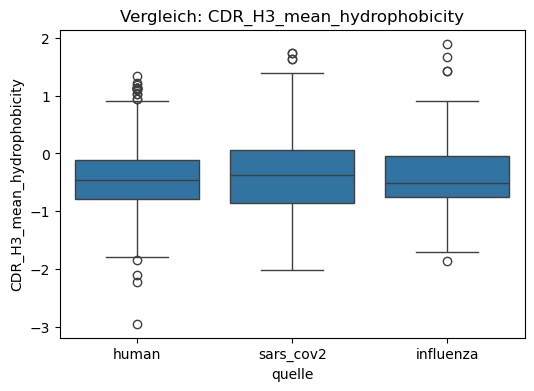

🔬 CDR_H3_mean_hydrophobicity – ANOVA p-Wert: 0.2851


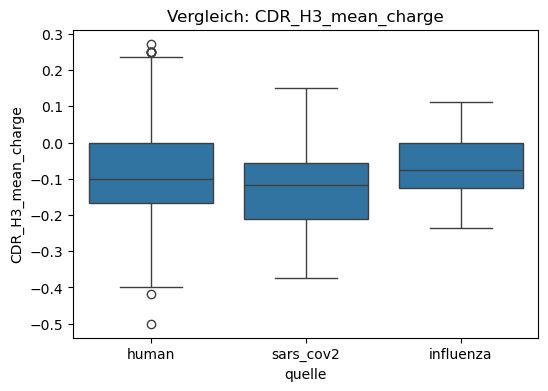

🔬 CDR_H3_mean_charge – ANOVA p-Wert: 0.0000


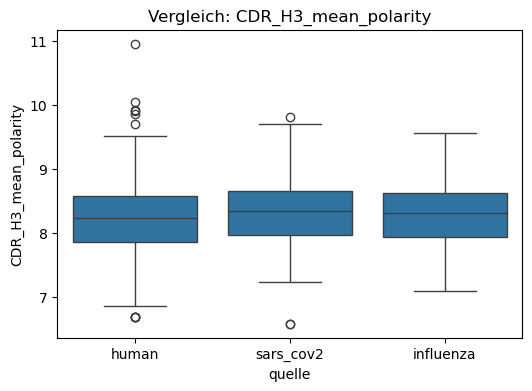

🔬 CDR_H3_mean_polarity – ANOVA p-Wert: 0.0022


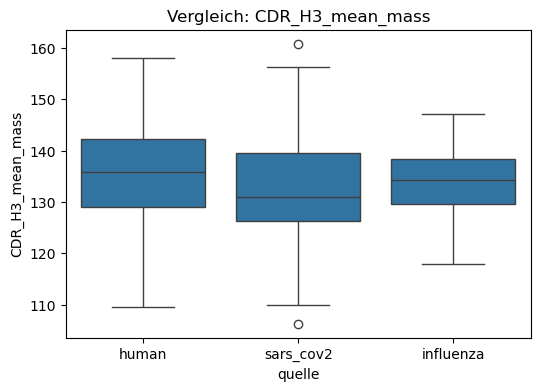

🔬 CDR_H3_mean_mass – ANOVA p-Wert: 0.0000


In [81]:
# Mittelwerte der Eigenschaften vergelchen von CDR H3
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# Wir analysieren CDR_H3
eigenschaften = ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass']

# Ergebnisse vorbereiten
frames = []
for name in ["human", "sars_cov2", "influenza"]:
    df = pd.read_csv(f"{name}_cdr_seq.tsv", sep="\t")
    df["quelle"] = name  # Herkunft der Daten
    frames.append(df)

# Kombinieren
alle = pd.concat(frames)

# Schleife durch alle Eigenschaften
for eig in eigenschaften:
    spalte = f'CDR_H3_{eig}'
    
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=alle, x='quelle', y=spalte)
    plt.title(f"Vergleich: {spalte}")
    plt.show()

    # ANOVA-Test
    human = alle[alle["quelle"] == "human"][spalte].dropna()
    sars = alle[alle["quelle"] == "sars_cov2"][spalte].dropna()
    influenza = alle[alle["quelle"] == "influenza"][spalte].dropna()
    
    f_stat, p_val = f_oneway(human, sars, influenza)
    print(f"🔬 {spalte} – ANOVA p-Wert: {p_val:.4f}")


/var/folders/s2/qtqytml16zj3cmryjfpnnl7r0000gn/T/ipykernel_2890/1729996844.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=means.index, y=means.values, palette="pastel")


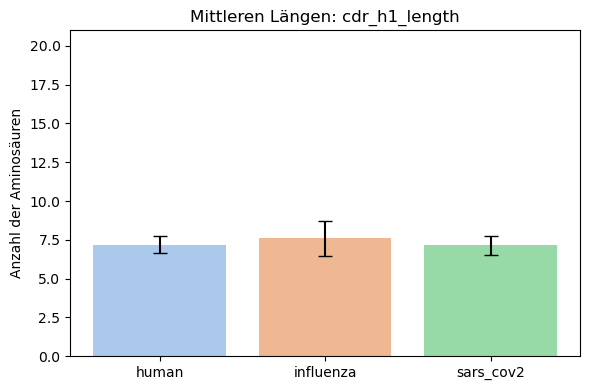

📊 cdr_h1_length – ANOVA p-Wert: 0.0000


/var/folders/s2/qtqytml16zj3cmryjfpnnl7r0000gn/T/ipykernel_2890/1729996844.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=means.index, y=means.values, palette="pastel")


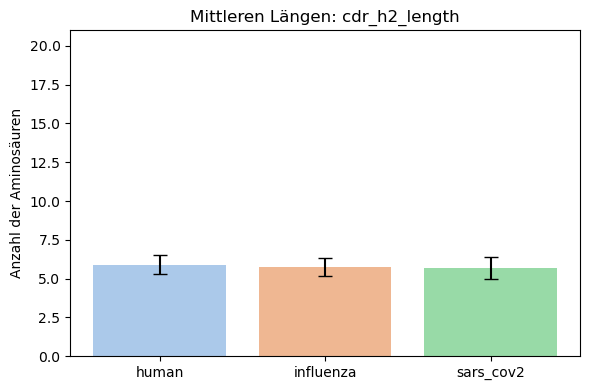

📊 cdr_h2_length – ANOVA p-Wert: 0.0000


/var/folders/s2/qtqytml16zj3cmryjfpnnl7r0000gn/T/ipykernel_2890/1729996844.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=means.index, y=means.values, palette="pastel")


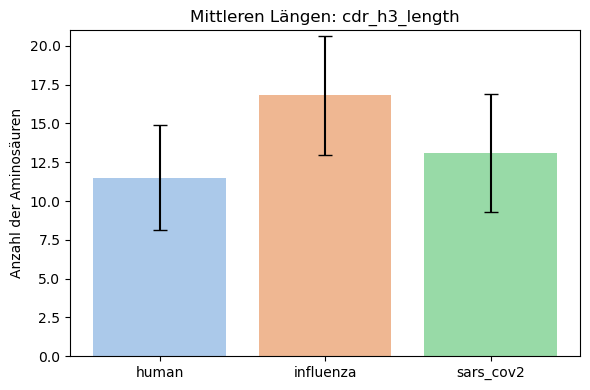

📊 cdr_h3_length – ANOVA p-Wert: 0.0000


In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

# Einheitliche y-Achsen-Skalierung 
y_limit = 21

for region in ["cdr_h1_length", "cdr_h2_length", "cdr_h3_length"]:
    plt.figure(figsize=(6, 4))

    # Gruppierte Mittel- und Standardabweichungen
    grouped = alle.groupby("quelle")[region].agg(['mean', 'std'])
    means = grouped["mean"]
    errors = grouped["std"]
    
    # Balkenplot mit Seaborn
    ax = sns.barplot(x=means.index, y=means.values, palette="pastel")

    # Fehlerbalken ergänzen
    for i, (mean, std) in enumerate(zip(means.values, errors.values)):
        plt.errorbar(x=i, y=mean, yerr=std, fmt='none', c='black', capsize=5)

    plt.title(f"Mittleren Längen: {region}")
    plt.ylabel("Anzahl der Aminosäuren")
    plt.xlabel("")
    plt.ylim(0, y_limit)  # Y-Achse begrenzen
    plt.tight_layout()
    plt.show()

    # ANOVA-Test
    h = alle[alle["quelle"] == "human"][region].dropna()
    s = alle[alle["quelle"] == "sars_cov2"][region].dropna()
    i = alle[alle["quelle"] == "influenza"][region].dropna()

    f_stat, p_val = f_oneway(h, s, i)
    print(f"📊 {region} – ANOVA p-Wert: {p_val:.4f}")

In [83]:


# Bereits bereinigte, angereicherte Datensätze einladen
df_sars = pd.read_csv("sars_cov2_cdr_seq.tsv", sep="\t")
df_influenza = pd.read_csv("influenza_cdr_seq.tsv", sep="\t")
df_human = pd.read_csv("human_cdr_seq.tsv", sep="\t")

#Überblick über die Zeilenanzahl
print("SARS-CoV-2:", len(df_sars))
print("Influenza:", len(df_influenza))
print("Human:", len(df_human))


#Fehlen irgendwo Daten?
print("Fehlende Werte SARS-CoV-2:")
print(df_sars.isna().sum())

print("\nFehlende Werte Influenza:")
print(df_influenza.isna().sum())

print("\nFehlende Werte Human:")
print(df_human.isna().sum())




SARS-CoV-2: 378
Influenza: 100
Human: 379
Fehlende Werte SARS-CoV-2:
pdb               0
heavy_chain       0
CDR_H3            0
CDR_H2            0
CDR_H1            0
                 ..
CDR_H3_count_Y    0
CDR_H3_count_V    0
cdr_h1_length     0
cdr_h2_length     0
cdr_h3_length     0
Length: 80, dtype: int64

Fehlende Werte Influenza:
pdb               0
heavy_chain       0
CDR_H3            0
CDR_H2            0
CDR_H1            0
                 ..
CDR_H3_count_Y    0
CDR_H3_count_V    0
cdr_h1_length     0
cdr_h2_length     0
cdr_h3_length     0
Length: 80, dtype: int64

Fehlende Werte Human:
pdb               0
heavy_chain       0
CDR_H3            0
CDR_H2            0
CDR_H1            0
                 ..
CDR_H3_count_Y    0
CDR_H3_count_V    0
cdr_h1_length     0
cdr_h2_length     0
cdr_h3_length     0
Length: 80, dtype: int64


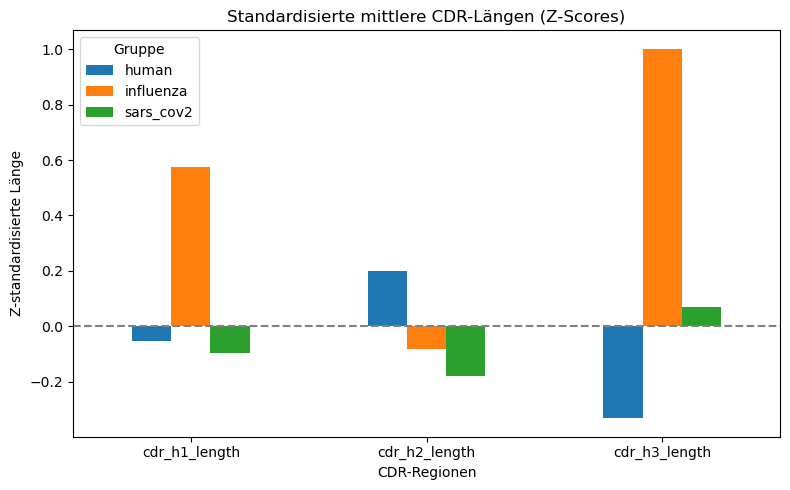

In [84]:
# Visualisierung der Längen 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Bereite deine drei bereinigten Datensätze vor
df_human = pd.read_csv("human_cdr_seq.tsv", sep="\t")
df_sars = pd.read_csv("sars_cov2_cdr_seq.tsv", sep="\t")
df_influenza = pd.read_csv("influenza_cdr_seq.tsv", sep="\t")

# Quelle markieren
df_human["quelle"] = "human"
df_sars["quelle"] = "sars_cov2"
df_influenza["quelle"] = "influenza"

# Alle kombinieren
alle = pd.concat([df_human, df_sars, df_influenza], ignore_index=True)

# CDR-Längen-Spalten
laengen = ["cdr_h1_length", "cdr_h2_length", "cdr_h3_length"]

# Z-Transformation (Standardisierung)
scaler = StandardScaler()
alle_z = alle.copy()
alle_z[laengen] = scaler.fit_transform(alle[laengen])

# Gruppieren: Mittelwert der Z-Scores pro Gruppe
z_mittelwerte = alle_z.groupby("quelle")[laengen].mean().reset_index()

# Balkendiagramm zeichnen
z_mittelwerte.set_index("quelle").T.plot(kind="bar", figsize=(8, 5))
plt.axhline(0, color='gray', linestyle='--')
plt.title("Standardisierte mittlere CDR-Längen (Z-Scores)")
plt.ylabel("Z-standardisierte Länge")
plt.xlabel("CDR-Regionen")
plt.xticks(rotation=0)
plt.legend(title="Gruppe")
plt.tight_layout()
plt.show()



Warum Z-Transformation?

= Die Längen der CDRs haben unterschiedliche Skalen. Mit der Z-Transformation (Standardisierung) bringen wir alle auf den gleichen Maßstab, sodass der Vergleich fair ist. Dabei gilt:

0 = Durchschnitt der Gruppe

positive Werte = länger als der Durchschnitt

negative Werte = kürzer als der Durchschnitt

## Interpretation Balkendiagramm

### CDR-H3:
- Influenza hat deutlich längere H3-Loops (Z ≈ +1.0)
- Human ist am kürzesten (Z ≈ –0.3)
- SARS-CoV-2 liegt leicht über dem Mittel (Z ≈ +0.1)

### CDR-H1 & H2:
- Unterschiede sind kleiner, aber:
- H1: Influenza wieder am längsten
- H2: Human am höchsten (leicht)

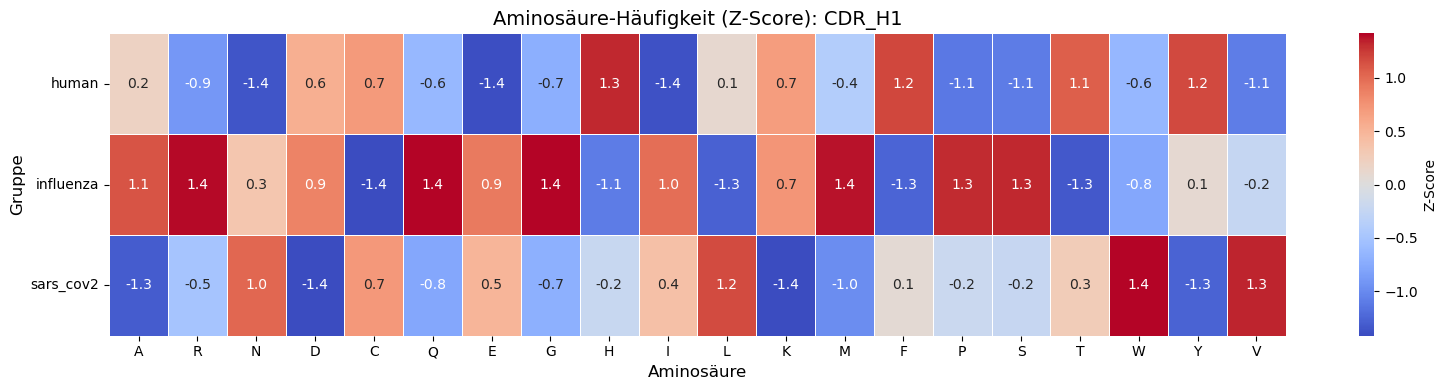

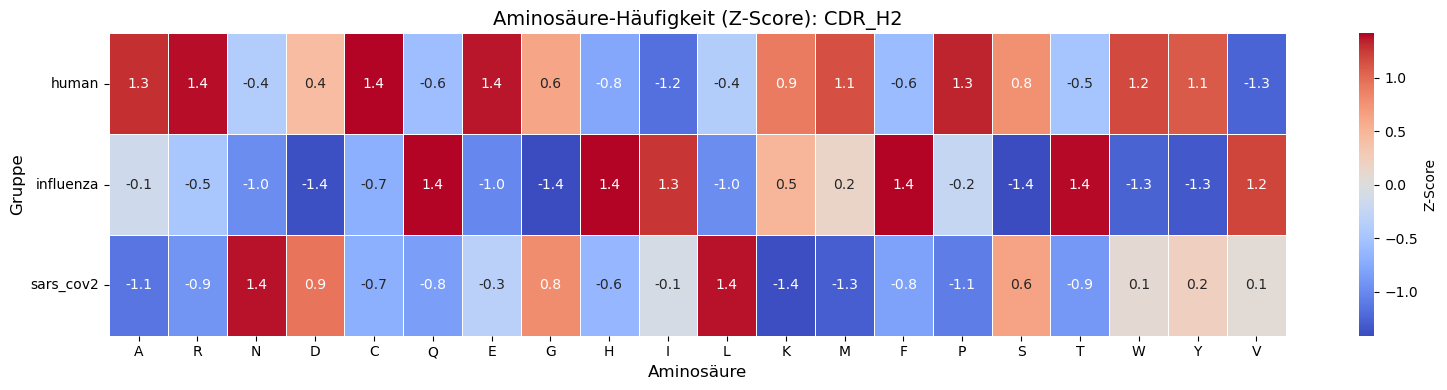

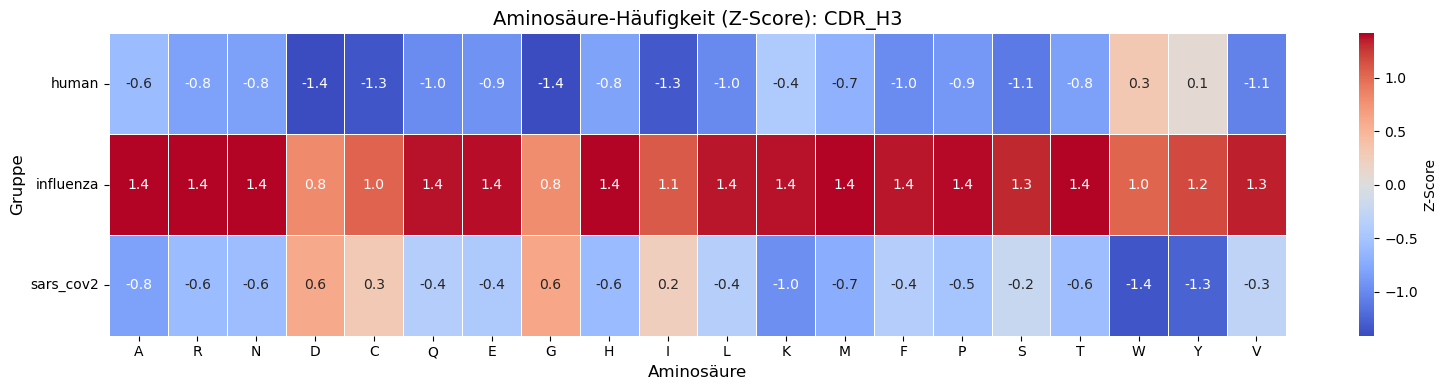

In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Datensätze laden
df_human = pd.read_csv("human_cdr_seq.tsv", sep="\t")
df_sars = pd.read_csv("sars_cov2_cdr_seq.tsv", sep="\t")
df_influenza = pd.read_csv("influenza_cdr_seq.tsv", sep="\t")

# Quelle hinzufügen
df_human["quelle"] = "human"
df_sars["quelle"] = "sars_cov2"
df_influenza["quelle"] = "influenza"

# Zusammenführen
alle = pd.concat([df_human, df_sars, df_influenza], ignore_index=True)

# CDRs und Aminosäuren
cdrs = ["CDR_H1", "CDR_H2", "CDR_H3"]
aminos = ['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I',
          'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']

# Für jede CDR eine besser lesbare Heatmap (Z-Score-basiert)
for cdr in cdrs:
    count_cols = [f"{cdr}_count_{aa}" for aa in aminos if f"{cdr}_count_{aa}" in alle.columns]

    grouped = alle.groupby("quelle")[count_cols].mean()

    # Z-Score
    scaler = StandardScaler()
    z_scaled = scaler.fit_transform(grouped)
    z_df = pd.DataFrame(z_scaled, columns=aminos, index=grouped.index)  # Nur AA-Kürzel als Spaltennamen

    # Plot
    plt.figure(figsize=(16, 4))
    sns.heatmap(z_df, cmap="coolwarm", center=0, annot=True, fmt=".1f",
                cbar_kws={"label": "Z-Score"}, linewidths=0.5,
                annot_kws={"size": 10})
    plt.title(f"Aminosäure-Häufigkeit (Z-Score): {cdr}", fontsize=14)
    plt.ylabel("Gruppe", fontsize=12)
    plt.xlabel("Aminosäure", fontsize=12)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


### Auffälligkeiten 

- Influenza hat die längsten CDR_H3 Regionen 

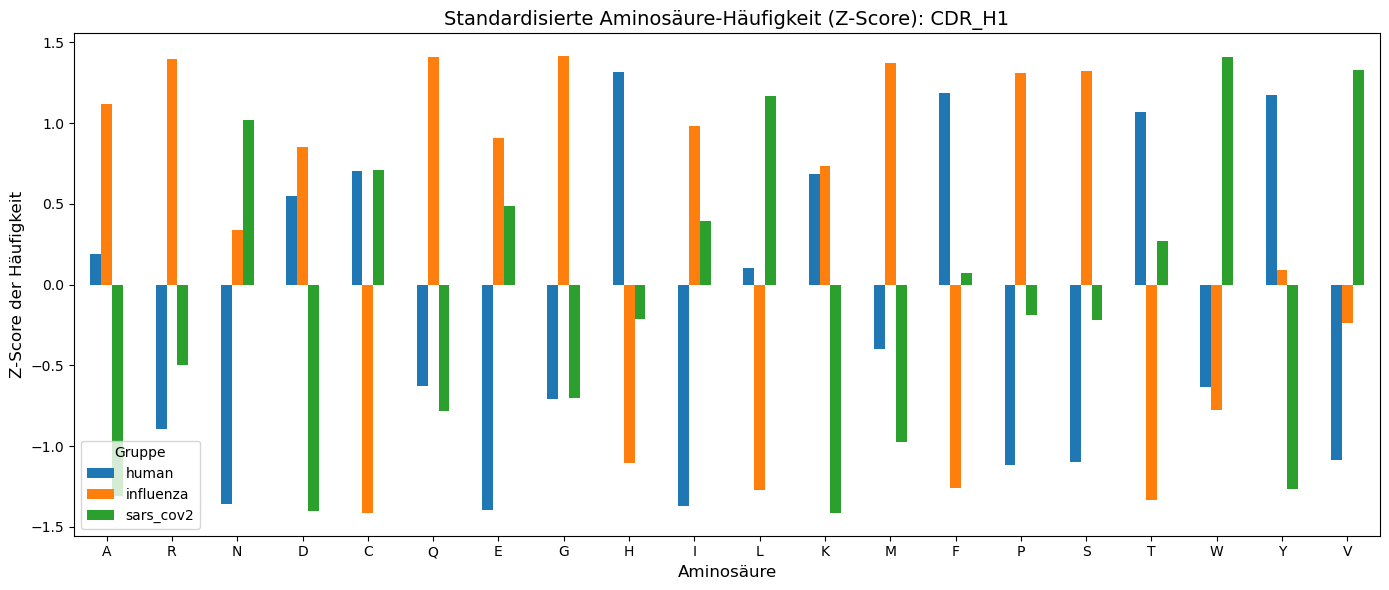

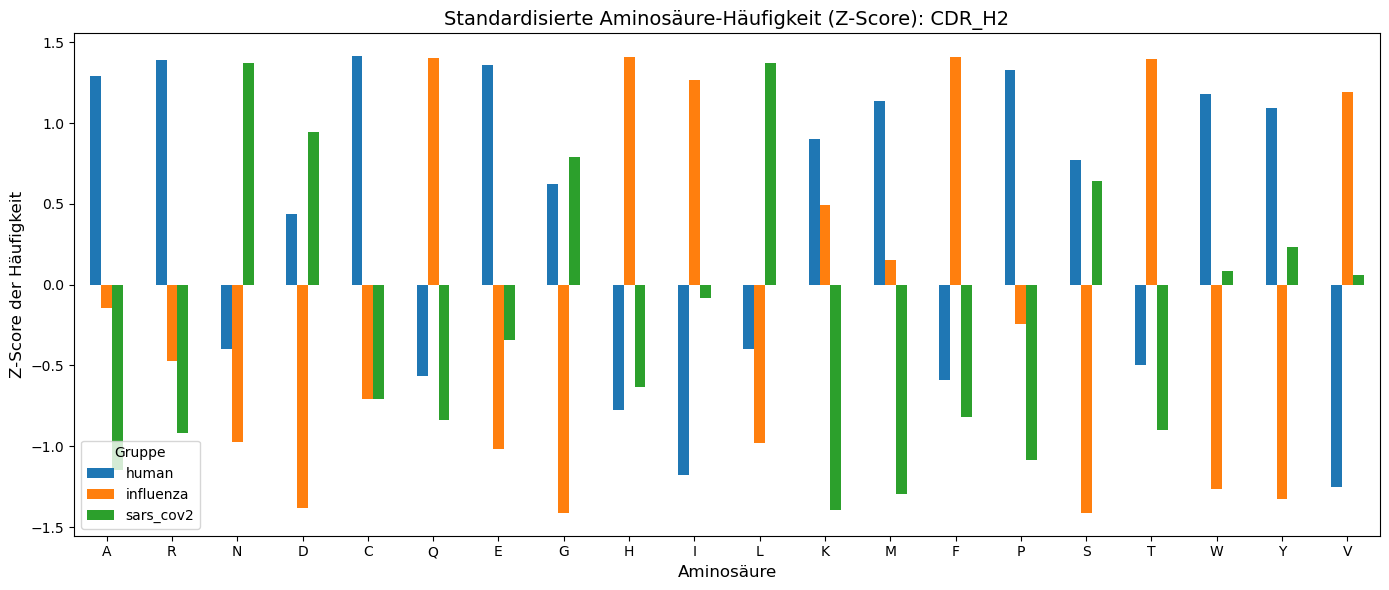

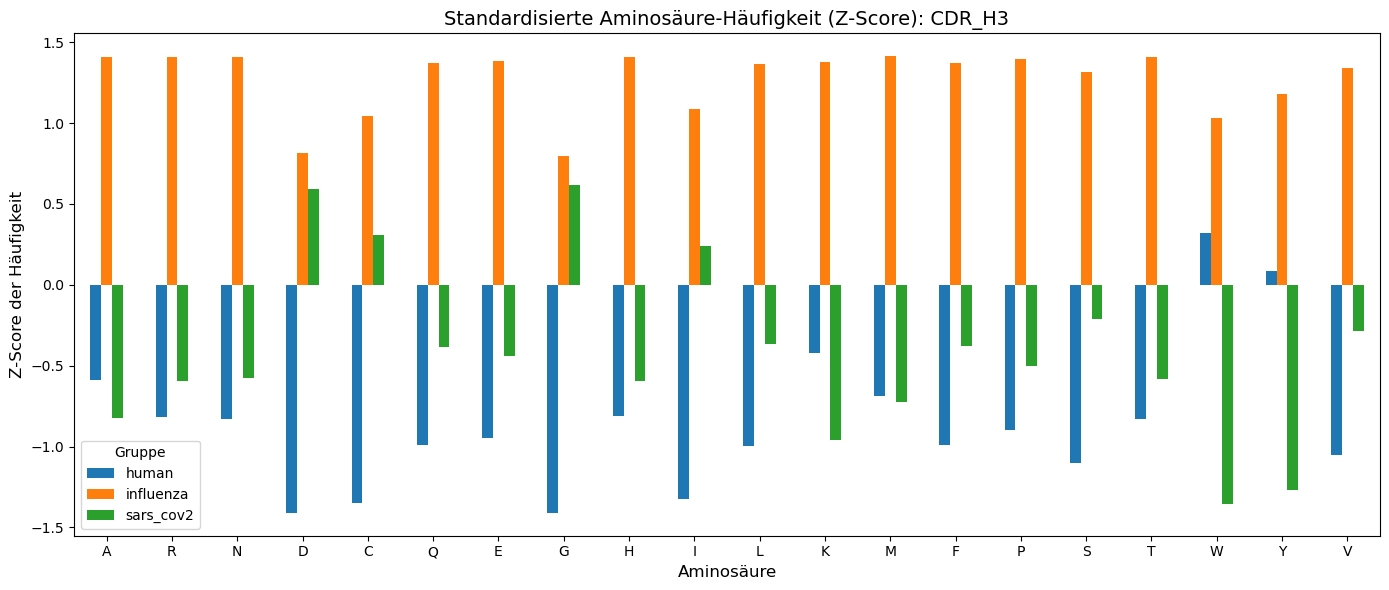

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Datensätze laden
df_human = pd.read_csv("human_cdr_seq.tsv", sep="\t")
df_sars = pd.read_csv("sars_cov2_cdr_seq.tsv", sep="\t")
df_influenza = pd.read_csv("influenza_cdr_seq.tsv", sep="\t")

# Quelle hinzufügen
df_human["quelle"] = "human"
df_sars["quelle"] = "sars_cov2"
df_influenza["quelle"] = "influenza"

# Zusammenführen
alle = pd.concat([df_human, df_sars, df_influenza], ignore_index=True)

# CDRs und Aminosäuren
cdrs = ["CDR_H1", "CDR_H2", "CDR_H3"]
aminos = ['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I',
          'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']

# Für jede CDR standardisierte Balkendiagramme
for cdr in cdrs:
    # Relevante Spalten sammeln
    count_cols = [f"{cdr}_count_{aa}" for aa in aminos if f"{cdr}_count_{aa}" in alle.columns]
    
    # Mittelwerte pro Gruppe
    grouped = alle.groupby("quelle")[count_cols].mean()
    grouped.columns = [col.replace(f"{cdr}_count_", "") for col in grouped.columns]  # Amino-Abkürzungen
    
    # Z-Score-Standardisierung (spaltenweise = über Gruppen)
    scaler = StandardScaler()
    z_scaled = scaler.fit_transform(grouped)
    z_df = pd.DataFrame(z_scaled, columns=grouped.columns, index=grouped.index)
    
    # Transponieren für bar-plot (Aminosäuren auf x-Achse)
    z_df.T.plot(kind="bar", figsize=(14, 6))
    plt.title(f"Standardisierte Aminosäure-Häufigkeit (Z-Score): {cdr}", fontsize=14)
    plt.xlabel("Aminosäure", fontsize=12)
    plt.ylabel("Z-Score der Häufigkeit", fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title="Gruppe")
    plt.tight_layout()
    plt.show()




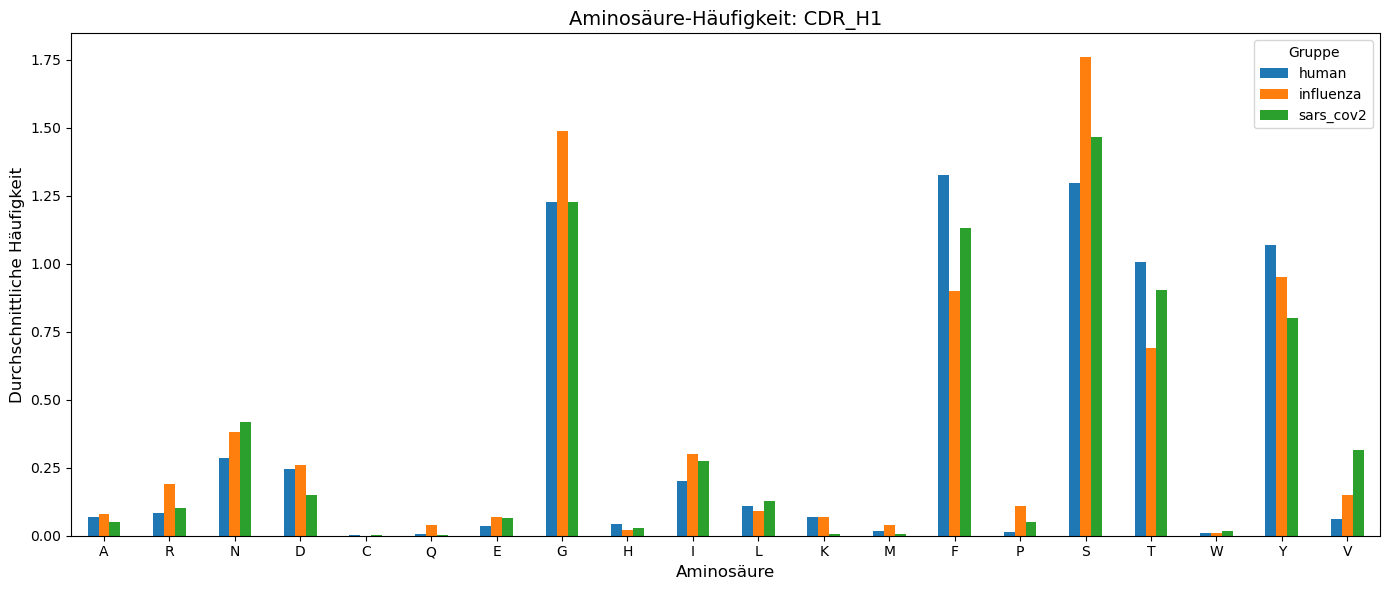

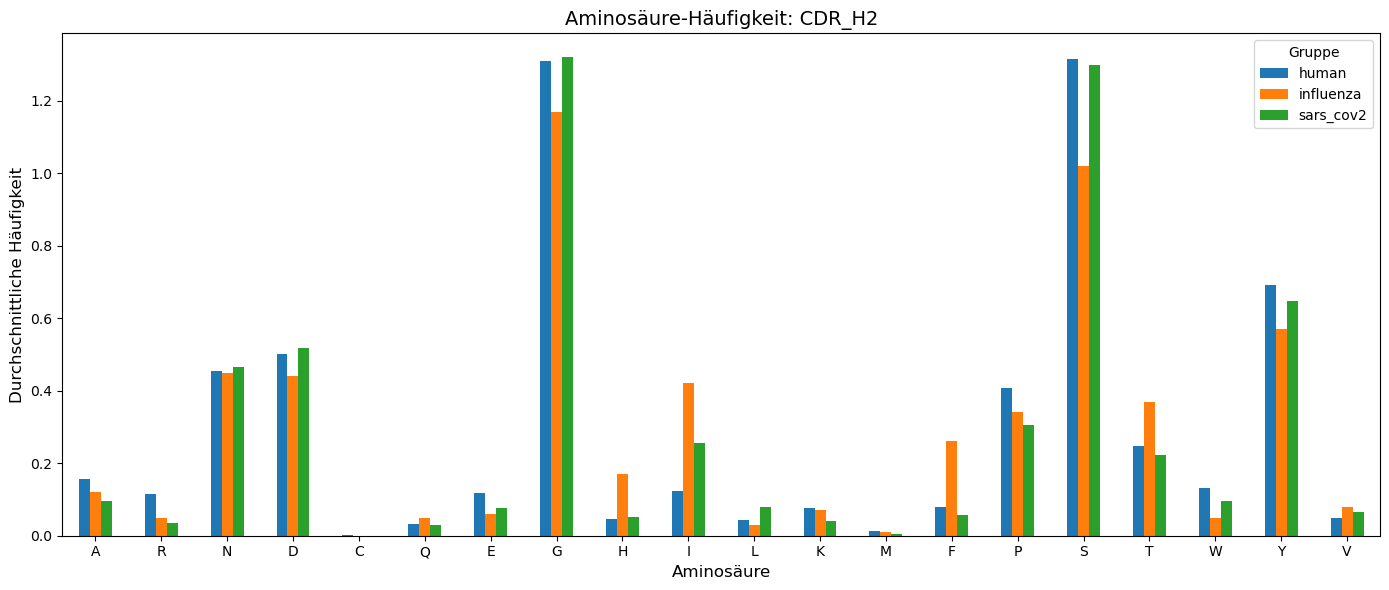

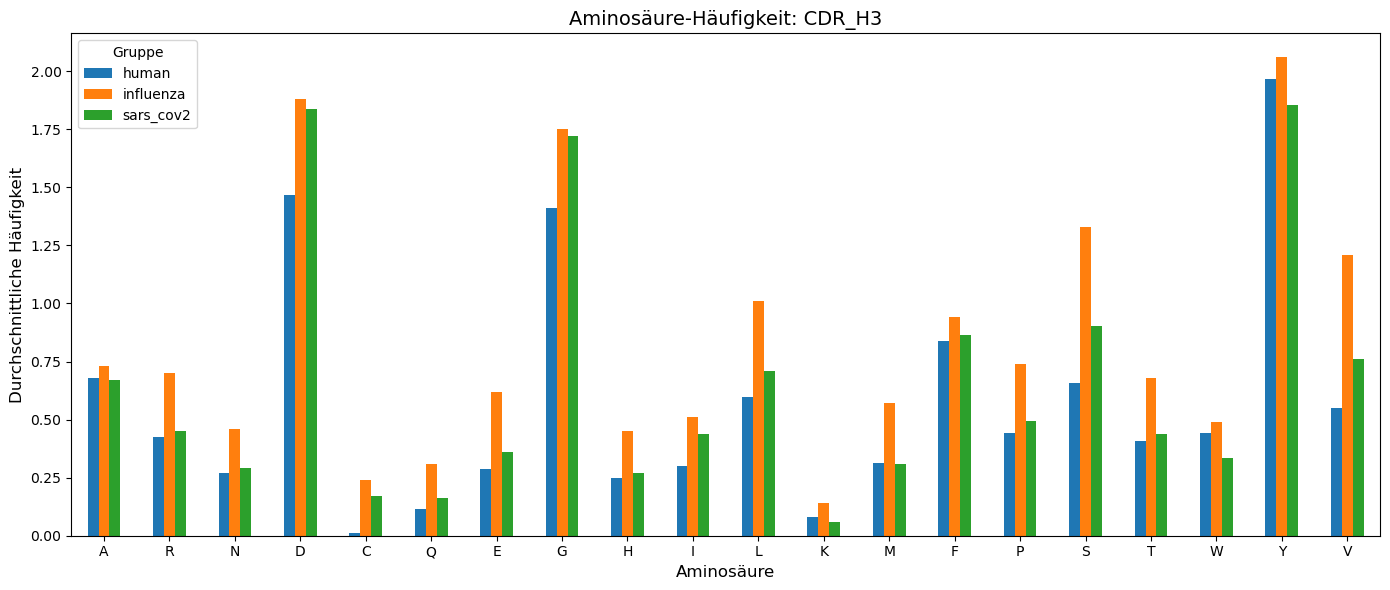

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

# Datensätze laden
df_human = pd.read_csv("human_cdr_seq.tsv", sep="\t")
df_sars = pd.read_csv("sars_cov2_cdr_seq.tsv", sep="\t")
df_influenza = pd.read_csv("influenza_cdr_seq.tsv", sep="\t")

# Quelle hinzufügen
df_human["quelle"] = "human"
df_sars["quelle"] = "sars_cov2"
df_influenza["quelle"] = "influenza"

# Zusammenführen
alle = pd.concat([df_human, df_sars, df_influenza], ignore_index=True)

# CDRs und Aminosäuren
cdrs = ["CDR_H1", "CDR_H2", "CDR_H3"]
aminos = ['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I',
          'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']

# Für jede CDR Balkendiagramm zeichnen
for cdr in cdrs:
    count_cols = [f"{cdr}_count_{aa}" for aa in aminos if f"{cdr}_count_{aa}" in alle.columns]
    
    grouped = alle.groupby("quelle")[count_cols].mean()

    # Umbenennung der Spalten zur besseren Anzeige
    grouped.columns = [col.replace(f"{cdr}_count_", "") for col in grouped.columns]

    # Balkendiagramm pro Gruppe
    ax = grouped.T.plot(kind="bar", figsize=(14, 6))
    ax.set_title(f"Aminosäure-Häufigkeit: {cdr}", fontsize=14)
    ax.set_xlabel("Aminosäure", fontsize=12)
    ax.set_ylabel("Durchschnittliche Häufigkeit", fontsize=12)
    ax.legend(title="Gruppe")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


### CHI 2 Test 

In [88]:
# Polare AS

import pandas as pd
from scipy.stats import chi2_contingency

# ✅ Dateien mit Sequenzdaten
dateien = {
    "human": "human_cdr_seq.tsv",
    "sars_cov2": "sars_cov2_cdr_seq.tsv",
    "influenza": "influenza_cdr_seq.tsv"
}

# ✅ Liste besonders polarer Aminosäuren
polare_aminosaeuren = ['S', 'T', 'N', 'Q', 'Y', 'C', 'D', 'E', 'K', 'R', 'H']

# ✅ Liste der zu untersuchenden CDR-Regionen
cdr_regionen = ["CDR_H1", "CDR_H2", "CDR_H3"]

# ✅ Für jede CDR-Region den Test durchführen
for cdr_region in cdr_regionen:
    print(f"\n============================")
    print(f"🔬 Analyse für {cdr_region}")
    print(f"============================")

    count_data = {}

    for quelle, path in dateien.items():
        df = pd.read_csv(path, sep="\t")

        # Spaltennamen für diese Region + Aminosäuren
        aa_cols = [f"{cdr_region}_count_{aa}" for aa in polare_aminosaeuren]

        # Summiere Aminosäuren
        summed = df[aa_cols].sum()
        summed.index = [col.replace(f"{cdr_region}_count_", "") for col in summed.index]
        count_data[quelle] = summed

    # Kontingenztabelle und Chi²-Test
    contingency_polar = pd.DataFrame(count_data).T

    print(f"\n📊 Kontingenztabelle (polare Aminosäuren in {cdr_region}):")
    print(contingency_polar)

    chi2, p, dof, expected = chi2_contingency(contingency_polar)

    print(f"\n🧪 Chi²-Test für {cdr_region}:")
    print(f"Chi²-Statistik: {chi2:.2f}")
    print(f"p-Wert: {p:.4f}")
    print(f"Freiheitsgrade: {dof}")



🔬 Analyse für CDR_H1

📊 Kontingenztabelle (polare Aminosäuren in CDR_H1):
               S      T      N    Q      Y    C     D     E     K     R     H
human      492.0  382.0  108.0  2.0  405.0  1.0  93.0  13.0  26.0  31.0  17.0
sars_cov2  554.0  341.0  158.0  1.0  303.0  1.0  57.0  24.0   3.0  38.0  11.0
influenza  176.0   69.0   38.0  4.0   95.0  0.0  26.0   7.0   7.0  19.0   2.0

🧪 Chi²-Test für CDR_H1:
Chi²-Statistik: 96.57
p-Wert: 0.0000
Freiheitsgrade: 20

🔬 Analyse für CDR_H2

📊 Kontingenztabelle (polare Aminosäuren in CDR_H2):
               S     T      N     Q      Y    C      D     E     K     R     H
human      499.0  94.0  172.0  12.0  262.0  1.0  190.0  45.0  29.0  44.0  17.0
sars_cov2  491.0  84.0  176.0  11.0  245.0  0.0  196.0  29.0  15.0  13.0  20.0
influenza  102.0  37.0   45.0   5.0   57.0  0.0   44.0   6.0   7.0   5.0  17.0

🧪 Chi²-Test für CDR_H2:
Chi²-Statistik: 64.22
p-Wert: 0.0000
Freiheitsgrade: 20

🔬 Analyse für CDR_H3

📊 Kontingenztabelle (polare Aminosäur

### Unterscheiden sich die Verteilungen polarer Aminosäuren in den CDR-Regionen (H1, H2, H3) zwischen Antikörpern aus dem Menschen, gegen SARS-CoV-2 und gegen Influenza signifikant?

- In allen drei CDR-Regionen gibt es signifikante Unterschiede in der Verteilung der polareren Aminosäuren zwischen den Gruppen.

- !! CDR-H3 hat größten Wert = zeigt größten unterschied in AS Verteilung

- p < 0.05 → Unterschied ist statistisch signifikant → du kannst H₀ ablehnen.
- p ≈ 0.0000 (wie bei dir) → der Unterschied ist sehr sicher nicht zufällig

In [90]:
# unpolare AS
import pandas as pd
from scipy.stats import chi2_contingency

# ✅ Dateien mit Sequenzdaten
dateien = {
    "human": "human_cdr_seq.tsv",
    "sars_cov2": "sars_cov2_cdr_seq.tsv",
    "influenza": "influenza_cdr_seq.tsv"
}

# ✅ Liste unpolarer (hydrophober) Aminosäuren
unpolare_aminosaeuren = ['A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']

# ✅ Zu analysierende CDR-Regionen
cdr_regionen = ["CDR_H1", "CDR_H2", "CDR_H3"]

# ✅ Schleife über alle CDRs
for cdr_region in cdr_regionen:
    print(f"\n============================")
    print(f"🔬 Analyse für {cdr_region} – unpolare Aminosäuren")
    print(f"============================")

    count_data = {}

    for quelle, path in dateien.items():
        df = pd.read_csv(path, sep="\t")

        # Spaltennamen für unpolare AS in dieser CDR-Region
        aa_cols = [f"{cdr_region}_count_{aa}" for aa in unpolare_aminosaeuren]

        # Summiere Häufigkeiten
        summed = df[aa_cols].sum()

        # Aminosäuren als Indexnamen (nur Buchstaben)
        summed.index = [col.replace(f"{cdr_region}_count_", "") for col in summed.index]

        # Speichern
        count_data[quelle] = summed

    # Kontingenztabelle erstellen
    contingency = pd.DataFrame(count_data).T

    # Ausgabe der Tabelle
    print(f"\n📊 Kontingenztabelle (unpolare Aminosäuren in {cdr_region}):")
    print(contingency)

    # Chi²-Test durchführen
    chi2, p, dof, expected = chi2_contingency(contingency)

    # Ergebnis ausgeben
    print(f"\n🧪 Chi²-Test für {cdr_region}:")
    print(f"Chi²-Statistik: {chi2:.2f}")
    print(f"p-Wert: {p:.4f}")
    print(f"Freiheitsgrade: {dof}")



🔬 Analyse für CDR_H1 – unpolare Aminosäuren

📊 Kontingenztabelle (unpolare Aminosäuren in CDR_H1):
              A      V      I     L    M      F    W     P      G
human      26.0   23.0   76.0  42.0  6.0  503.0  4.0   5.0  465.0
sars_cov2  19.0  119.0  104.0  48.0  3.0  428.0  7.0  19.0  464.0
influenza   8.0   15.0   30.0   9.0  4.0   90.0  1.0  11.0  149.0

🧪 Chi²-Test für CDR_H1:
Chi²-Statistik: 118.87
p-Wert: 0.0000
Freiheitsgrade: 16

🔬 Analyse für CDR_H2 – unpolare Aminosäuren

📊 Kontingenztabelle (unpolare Aminosäuren in CDR_H2):
              A     V     I     L    M     F     W      P      G
human      59.0  19.0  47.0  16.0  5.0  30.0  50.0  154.0  496.0
sars_cov2  36.0  25.0  97.0  30.0  2.0  22.0  36.0  115.0  499.0
influenza  12.0   8.0  42.0   3.0  1.0  26.0   5.0   34.0  117.0

🧪 Chi²-Test für CDR_H2:
Chi²-Statistik: 95.79
p-Wert: 0.0000
Freiheitsgrade: 16

🔬 Analyse für CDR_H3 – unpolare Aminosäuren

📊 Kontingenztabelle (unpolare Aminosäuren in CDR_H3):
             

/var/folders/s2/qtqytml16zj3cmryjfpnnl7r0000gn/T/ipykernel_2890/2653574854.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=summary_df, x="CDR", y="Anteil", hue="Eigenschaft", ci=None, palette="coolwarm")


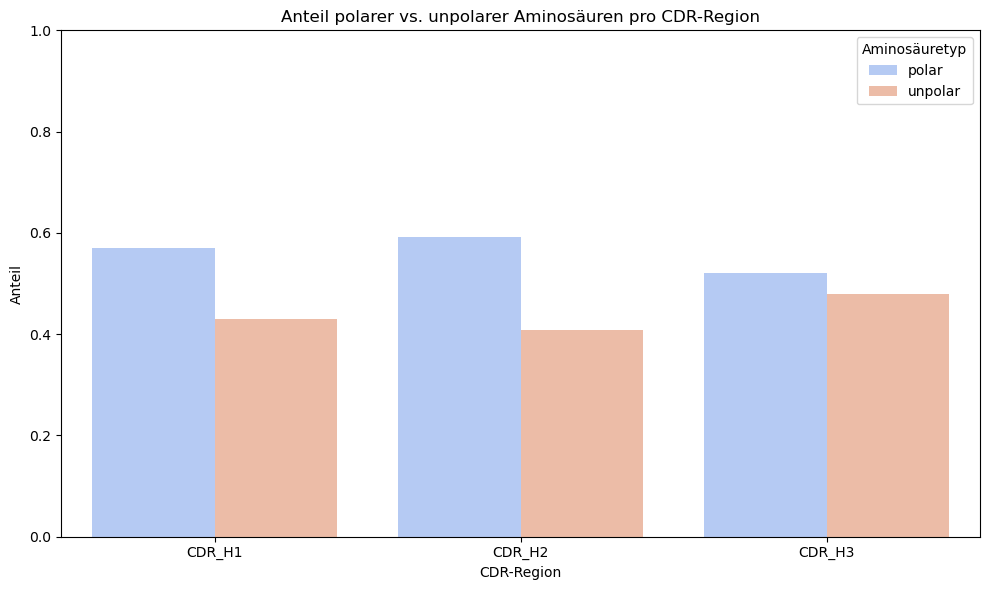

In [92]:
# Verhältnis polar/unpolar je CDR berechnen
summary_df["gesamt"] = summary_df.groupby(["CDR", "Quelle"])["Summe"].transform("sum")
summary_df["Anteil"] = summary_df["Summe"] / summary_df["gesamt"]

# Plot als Verhältnis
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=summary_df, x="CDR", y="Anteil", hue="Eigenschaft", ci=None, palette="coolwarm")
plt.title("Anteil polarer vs. unpolarer Aminosäuren pro CDR-Region")
plt.ylabel("Anteil")
plt.xlabel("CDR-Region")
plt.ylim(0, 1)
plt.legend(title="Aminosäuretyp")
plt.tight_layout()
plt.show()
